In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [13]:
df = pd.read_csv('heart.csv')



In [14]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Exploratory Data Analysis

In [15]:
df.shape

(918, 12)

In [16]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [19]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [21]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [23]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

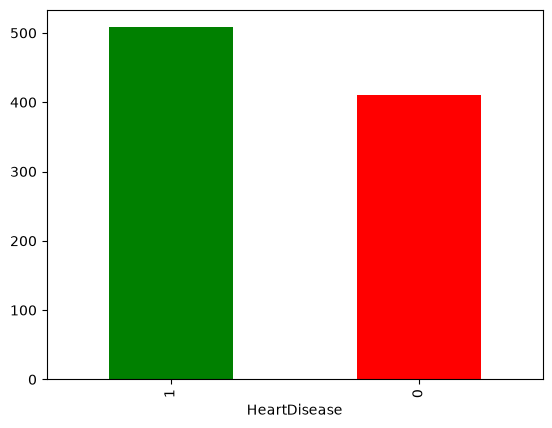

In [27]:
df['HeartDisease'].value_counts().plot(kind='bar', color=['green', 'red'])

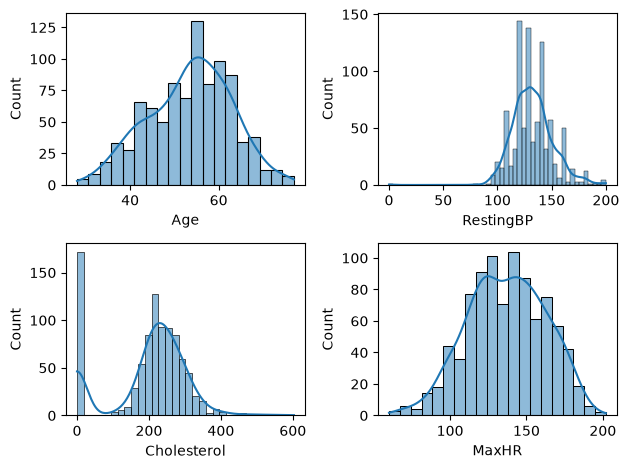

In [30]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()



In [31]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [32]:
ch_mean=df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [35]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'].round(2)

0      289.0
1      180.0
2      283.0
3      214.0
4      195.0
       ...  
913    264.0
914    193.0
915    131.0
916    236.0
917    175.0
Name: Cholesterol, Length: 918, dtype: float64

In [36]:
restting_bp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean()
df['RestingBP']=df['RestingBP'].replace(0,restting_bp_mean)
df['RestingBP'].round(2)

0      140.0
1      160.0
2      130.0
3      138.0
4      150.0
       ...  
913    110.0
914    144.0
915    130.0
916    130.0
917    138.0
Name: RestingBP, Length: 918, dtype: float64

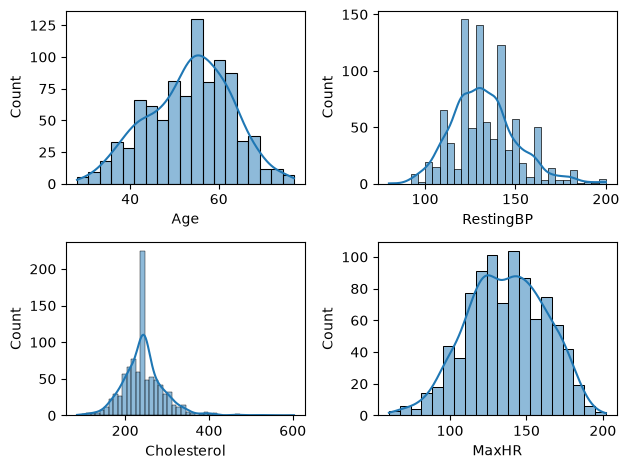

In [37]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()


In [38]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(storage='python', na_value=nan)>,
  'ChestPainType': <StringDtype(storage='python', na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(storage='python', na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(storage='python', na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(storage='python', na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'c

<Axes: xlabel='Sex', ylabel='count'>

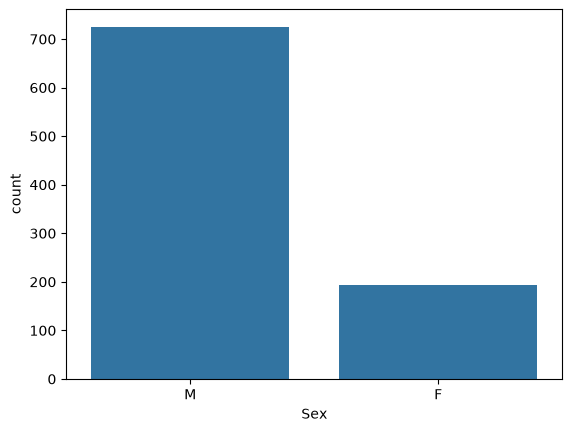

In [40]:
sns.countplot(x=df['Sex'])

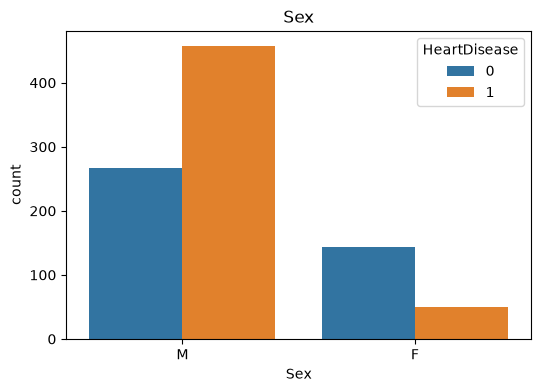

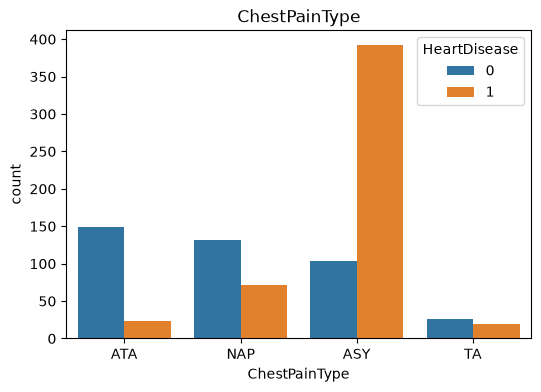

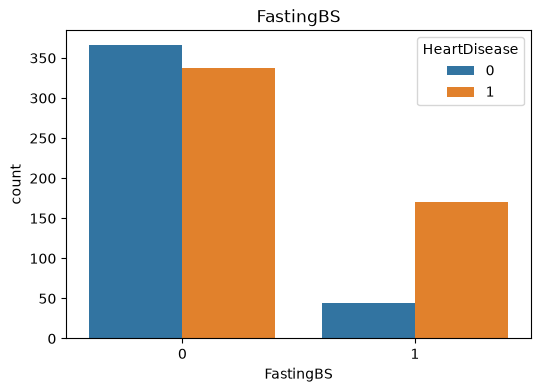

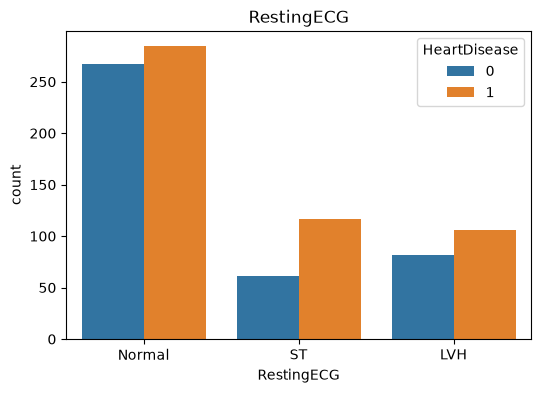

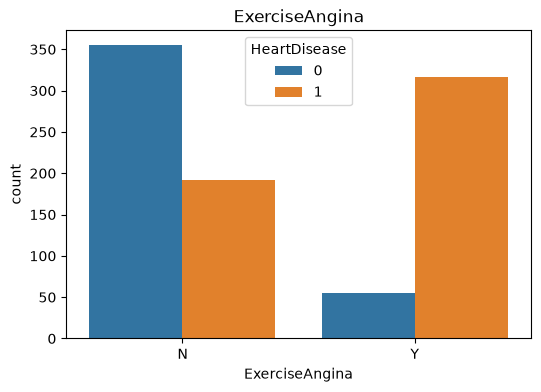

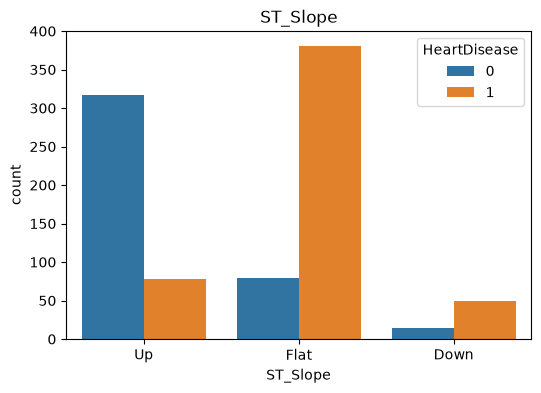

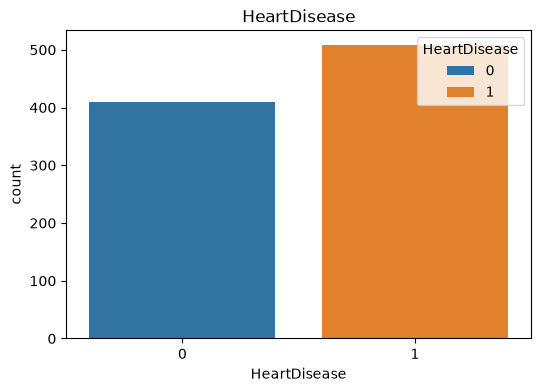

In [45]:
Categorical_Columns= ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']
for col in Categorical_Columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col],hue=df['HeartDisease'])  
    plt.title(col)
    plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

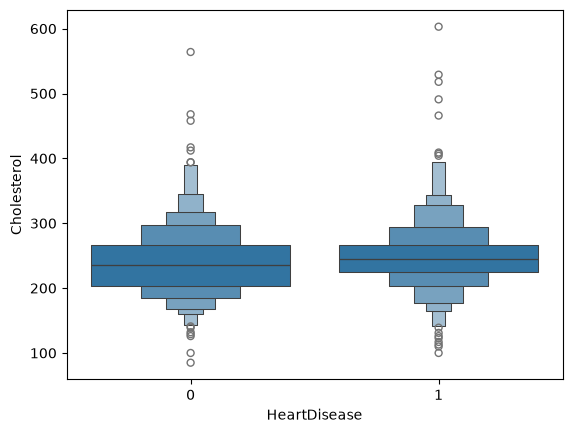

In [49]:
sns.boxenplot(x=df['HeartDisease'],y=df['Cholesterol'],data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

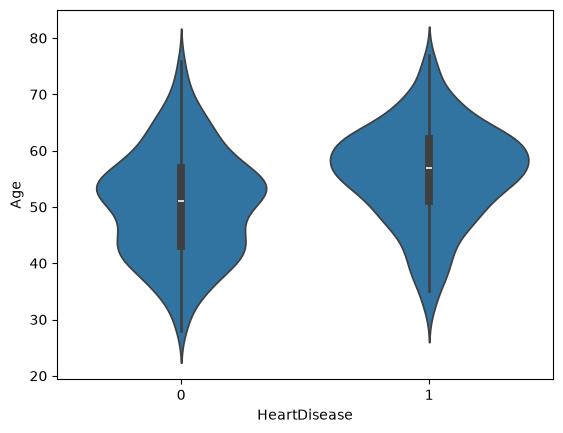

In [50]:
sns.violinplot(x=df['HeartDisease'],y=df['Age'],data=df)

<Axes: >

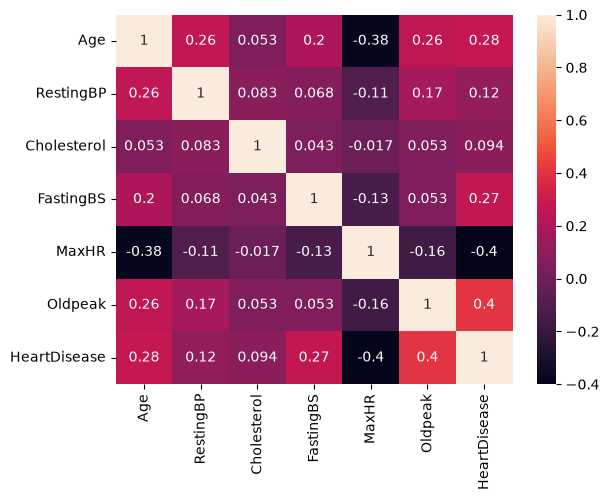

In [52]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data PreProcessing

In [62]:
df_encode=pd.get_dummies(df,drop_first=True)
df_encode=df_encode.astype('int')


In [63]:
from sklearn.preprocessing import StandardScaler
Numerical_Columns= ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler=StandardScaler()
df_encode[Numerical_Columns]=scaler.fit_transform(df_encode[Numerical_Columns])
df_encode.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


# Feature Extraction

In [76]:
from scipy.stats import pearsonr

# Pearson Correlation Calculation
# ---------------------------------

# List of numeric features to check against target
selected_features = [
    'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'
]

correlations = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
}

correlations_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlations_df = correlations_df.sort_values(
    by='Pearson Correlation',
    ascending=False
)

correlations_df

,Feature,Pearson Correlation
4,Oldpeak,0.392385
0,Age,0.282039
1,RestingBP,0.117909
2,Cholesterol,0.092586
3,MaxHR,-0.400421


In [79]:
from scipy.stats import chi2_contingency

alpha = 0.05

# categorical columns from df_encode
cat_features = [
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

chi2_results = {}

for feature in cat_features:
    contingency = pd.crosstab(df_encode[feature], df_encode['HeartDisease'])
    chi2_stat, p_value, _, _ = chi2_contingency(contingency)

    decision = 'Keep Feature' if p_value < alpha else 'Drop Feature'

    chi2_results[feature] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T.reset_index().rename(columns={'index': 'Feature'})


chi2_df

,Feature,chi2_statistic,p_value,Decision
0,Sex_M,84.145101,0.0,Keep Feature
1,ChestPainType_ATA,146.236323,0.0,Keep Feature
2,ChestPainType_NAP,40.608711,0.0,Keep Feature
3,ChestPainType_TA,2.273802,0.131577,Drop Feature
4,RestingECG_Normal,7.327532,0.006791,Keep Feature
5,RestingECG_ST,9.135266,0.002507,Keep Feature
6,ExerciseAngina_Y,222.259383,0.0,Keep Feature
7,ST_Slope_Flat,279.659914,0.0,Keep Feature
8,ST_Slope_Up,352.823905,0.0,Keep Feature


In [81]:
# Final feature selection from encoded + standardized data
selected_features = [
    'Age',
    'MaxHR',
    'Oldpeak',
    'Sex_M',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    'ChestPainType_TA',
    'RestingECG_Normal',
    'RestingECG_ST',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up',
    'HeartDisease'
]

final_df = df_encode[selected_features].copy()
final_df.head()

,Age,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,-1.433140,1.382928,-0.727592,1,1,0,0,1,0,0,0,1,0
1,-0.478484,0.754157,0.282891,0,0,1,0,1,0,0,1,0,1
2,-1.751359,-1.525138,-0.727592,1,1,0,0,0,1,0,0,1,0
3,-0.584556,-1.132156,0.282891,0,0,0,0,1,0,1,1,0,1
4,0.051881,-0.581981,-0.727592,1,0,1,0,1,0,0,0,1,0
